In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import colormaps
list(colormaps)
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [161]:
df = pd.read_csv("train.csv")

In [162]:
df.head(10)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
5,5,42,1,100,4.4,6.4,5.3,25.5,0.84,111,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
6,6,41,2,148,3.4,5.6,3.7,27.9,0.89,130,...,Female,White,Graduate,Lower-Middle,Current,Employed,0,0,0,1.0
7,7,51,3,102,4.0,7.3,5.5,27.1,0.83,125,...,Male,Asian,Highschool,Low,Never,Employed,1,0,0,1.0
8,8,34,2,44,2.7,7.0,7.9,22.6,0.81,120,...,Male,White,Highschool,Lower-Middle,Never,Employed,0,0,0,0.0
9,9,44,1,36,5.8,5.7,6.6,29.3,0.88,110,...,Male,Hispanic,Highschool,Middle,Never,Employed,1,0,0,1.0


In [163]:
df.tail()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0
699999,699999,42,4,56,4.2,7.0,6.1,28.3,0.90,99,...,Female,Black,Graduate,Low,Former,Employed,0,0,0,1.0


In [164]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,700000.0,349999.500000,202072.738554,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00


In [165]:
df.describe(include="object").T

,count,unique,top,freq
gender,700000,3,Female,363237
ethnicity,700000,5,White,386153
education_level,700000,4,Highschool,344145
income_level,700000,5,Middle,290557
smoking_status,700000,3,Never,494448
employment_status,700000,4,Employed,516170


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [167]:
df.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [168]:
df.duplicated().sum()

np.int64(0)

In [169]:
df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

In [170]:
skewed_features = [
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "screen_time_hours_per_day",
    "triglycerides",
    "bmi"
]

for col in skewed_features:
    df[col] = np.log1p(df[col])

In [171]:
df[skewed_features].skew()

alcohol_consumption_per_week          0.301759
physical_activity_minutes_per_week   -0.051182
screen_time_hours_per_day            -0.837458
triglycerides                        -0.635089
bmi                                  -0.294451
dtype: float64

In [172]:
kurt = df.select_dtypes(include="number").kurt()
kurt.sort_values(ascending=False)

cardiovascular_history                28.008350
family_history_diabetes                1.869041
triglycerides                          1.550987
screen_time_hours_per_day              1.069547
physical_activity_minutes_per_week     0.985453
hypertension_history                   0.717300
bmi                                    0.173435
waist_to_hip_ratio                     0.011097
diastolic_bp                          -0.037275
sleep_hours_per_day                   -0.059950
heart_rate                            -0.061064
hdl_cholesterol                       -0.107150
ldl_cholesterol                       -0.132099
diet_score                            -0.161252
cholesterol_total                     -0.266343
age                                   -0.386740
systolic_bp                           -0.393847
alcohol_consumption_per_week          -0.865486
id                                    -1.200000
diagnosed_diabetes                    -1.741027
dtype: float64

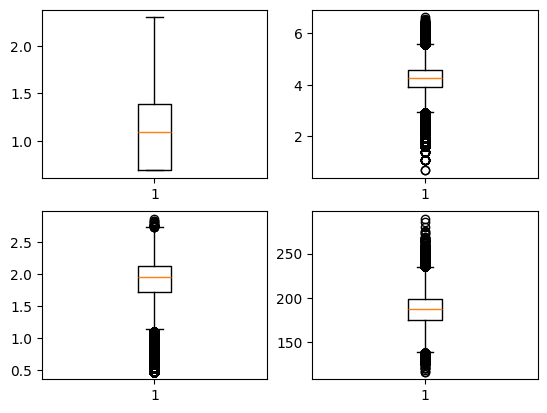

In [173]:
fig, ax = plt.subplots(2,2)
ax[0][0].boxplot(df['alcohol_consumption_per_week'] , showfliers = True);
ax[0][1].boxplot(df['physical_activity_minutes_per_week'] , showfliers = True);
ax[1][0].boxplot(df['screen_time_hours_per_day'] , showfliers = True);
ax[1][1].boxplot(df['cholesterol_total'] , showfliers = True);

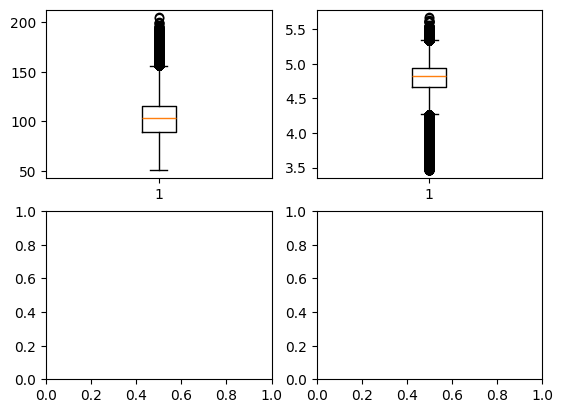

In [174]:
fig, ax = plt.subplots(2,2)
ax[0][0].boxplot(df['ldl_cholesterol'] , showfliers = True);
ax[0][1].boxplot(df['triglycerides'] , showfliers = True);

In [189]:
Q1 = df.alcohol_consumption_per_week.quantile(0.25)
Q2 = df.alcohol_consumption_per_week.quantile(0.50)
Q3 = df.alcohol_consumption_per_week.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)
df = df[(df['alcohol_consumption_per_week'] >= LC) & (df['alcohol_consumption_per_week'] <= UC)].reset_index(drop=True)

np.float64(-0.3465735902799726)

np.float64(2.4260151319598084)

In [190]:
Q1 = df.physical_activity_minutes_per_week.quantile(0.25)
Q2 = df.physical_activity_minutes_per_week.quantile(0.50)
Q3 = df.physical_activity_minutes_per_week.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)
df = df[(df['physical_activity_minutes_per_week'] >= LC) & (df['physical_activity_minutes_per_week'] <= UC)].reset_index(drop=True)

np.float64(2.917991045815291)

np.float64(5.568742938116238)

In [191]:
Q1 = df.screen_time_hours_per_day.quantile(0.25)
Q2 = df.screen_time_hours_per_day.quantile(0.50)
Q3 = df.screen_time_hours_per_day.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)
df = df[(df['screen_time_hours_per_day'] >= LC) & (df['screen_time_hours_per_day'] <= UC)].reset_index(drop=True)

np.float64(1.1145689355788568)

np.float64(2.7364293680115144)

In [192]:
Q1 = df.cholesterol_total.quantile(0.25)
Q2 = df.cholesterol_total.quantile(0.50)
Q3 = df.cholesterol_total.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)
df = df[(df['cholesterol_total'] >= LC) & (df['cholesterol_total'] <= UC)].reset_index(drop=True)

np.float64(139.0)

np.float64(235.0)

In [193]:
Q1 = df.ldl_cholesterol.quantile(0.25)
Q2 = df.ldl_cholesterol.quantile(0.50)
Q3 = df.ldl_cholesterol.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)
df = df[(df['ldl_cholesterol'] >= LC) & (df['ldl_cholesterol'] <= UC)].reset_index(drop=True)

np.float64(48.5)

np.float64(156.5)

In [194]:
Q1 = df.triglycerides.quantile(0.25)
Q2 = df.triglycerides.quantile(0.50)
Q3 = df.triglycerides.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)
df = df[(df['triglycerides'] >= LC) & (df['triglycerides'] <= UC)].reset_index(drop=True)

np.float64(4.280361186458727)

np.float64(5.32694158113387)

In [195]:
cat_col = df.select_dtypes(include=["object","category"]).columns.tolist
cat_col

<bound method IndexOpsMixin.tolist of Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'smoking_status', 'employment_status'],
      dtype='object')>

In [196]:
cf = pd.get_dummies(df, columns=['gender', 'ethnicity', 'education_level', 'income_level',
       'smoking_status', 'employment_status'], drop_first=False)

In [197]:
cf.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,0,31,0.693147,3.828641,7.7,6.8,1.960095,3.538057,0.93,112,...,True,False,False,True,False,False,True,False,False,False
1,1,50,1.098612,4.304065,5.7,6.5,1.916923,3.210844,0.83,120,...,False,False,True,False,False,True,True,False,False,False
2,2,32,1.386294,5.068904,8.5,7.4,2.312535,3.222868,0.83,95,...,True,False,False,False,False,True,False,True,False,False
3,3,54,1.386294,4.356709,4.6,7.0,2.322388,3.317816,0.83,121,...,True,False,False,True,False,False,True,False,False,False
4,4,54,0.693147,4.025352,5.7,6.2,1.808289,3.394508,0.90,108,...,False,False,True,False,False,True,False,True,False,False


In [198]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650386 entries, 0 to 650385
Data columns (total 44 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  650386 non-null  int64  
 1   age                                 650386 non-null  int64  
 2   alcohol_consumption_per_week        650386 non-null  float64
 3   physical_activity_minutes_per_week  650386 non-null  float64
 4   diet_score                          650386 non-null  float64
 5   sleep_hours_per_day                 650386 non-null  float64
 6   screen_time_hours_per_day           650386 non-null  float64
 7   bmi                                 650386 non-null  float64
 8   waist_to_hip_ratio                  650386 non-null  float64
 9   systolic_bp                         650386 non-null  int64  
 10  diastolic_bp                        650386 non-null  int64  
 11  heart_rate                

In [267]:
cat_col = cf.select_dtypes(include=["int","bool"]).columns.tolist
cat_col

<bound method IndexOpsMixin.tolist of Index(['id', 'age', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'gender_Female', 'gender_Male',
       'gender_Other', 'ethnicity_Asian', 'ethnicity_Black',
       'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White',
       'education_level_Graduate', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_High', 'income_level_Low', 'income_level_Lower-Middle',
       'income_level_Middle', 'income_level_Upper-Middle',
       'smoking_status_Current', 'smoking_status_Former',
       'smoking_status_Never', 'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Student',
       'employment_status_Unemployed'],
      dtype='object')>

In [291]:
X = cf.drop(columns=["diagnosed_diabetes", "id" ,'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Student',
       'employment_status_Unemployed' , 'education_level_Graduate', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_High', 'income_level_Low', 'income_level_Lower-Middle',
       'income_level_Middle', 'income_level_Upper-Middle'])
y = cf["diagnosed_diabetes"]

In [301]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [302]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

diagnosed_diabetes
1.0    0.627647
0.0    0.372353
Name: proportion, dtype: float64
diagnosed_diabetes
1.0    0.627647
0.0    0.372353
Name: proportion, dtype: float64
diagnosed_diabetes
1.0    0.627646
0.0    0.372354
Name: proportion, dtype: float64


In [303]:
y_train.mean(), y_test.mean()

(np.float64(0.6276474703444883), np.float64(0.6276464890296591))

In [304]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score, classification_report, roc_auc_score, confusion_matrix)

In [305]:
rf = RandomForestClassifier(
    n_estimators = 300 ,
    max_depth = 50,
    min_samples_leaf = 50,
    random_state = 42,
    n_jobs = -1,
    class_weight = "balanced"
)

In [306]:
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [307]:
feat_imp = pd.Series(rf.feature_importances_, index = X_train.columns)
feat_imp.sort_values(ascending=False).head(30)

family_history_diabetes               0.274964
physical_activity_minutes_per_week    0.171650
age                                   0.126521
bmi                                   0.049636
triglycerides                         0.049219
systolic_bp                           0.043917
ldl_cholesterol                       0.042569
cholesterol_total                     0.034004
diet_score                            0.032070
screen_time_hours_per_day             0.027618
hdl_cholesterol                       0.026337
heart_rate                            0.022758
sleep_hours_per_day                   0.022294
waist_to_hip_ratio                    0.021580
diastolic_bp                          0.020991
alcohol_consumption_per_week          0.007462
ethnicity_White                       0.004640
gender_Male                           0.004422
gender_Female                         0.004418
smoking_status_Never                  0.002700
hypertension_history                  0.002282
ethnicity_His

In [308]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]
y_pred_thr = (y_prob >= 0.55).astype(int)

In [309]:
print("accuracy : " , accuracy_score(y_test, y_pred))
print("ROC_AUC : " , roc_auc_score(y_test, y_pred))
print(confusion_matrix(y_test , y_pred))
print(classification_report(y_test , y_pred))
print("accuracy : " , accuracy_score(y_test, y_pred_thr))
print("ROC_AUC : " , roc_auc_score(y_test, y_pred_thr))
print(confusion_matrix(y_test , y_pred_thr))
print(classification_report(y_test , y_pred_thr))

accuracy :  0.6312673934101077
ROC_AUC :  0.6379669898106028
[[32171 16264]
 [31700 49943]]
              precision    recall  f1-score   support

         0.0       0.50      0.66      0.57     48435
         1.0       0.75      0.61      0.68     81643

    accuracy                           0.63    130078
   macro avg       0.63      0.64      0.62    130078
weighted avg       0.66      0.63      0.64    130078

accuracy :  0.5941742646719661
ROC_AUC :  0.6331742638443124
[[38067 10368]
 [42421 39222]]
              precision    recall  f1-score   support

         0.0       0.47      0.79      0.59     48435
         1.0       0.79      0.48      0.60     81643

    accuracy                           0.59    130078
   macro avg       0.63      0.63      0.59    130078
weighted avg       0.67      0.59      0.60    130078



In [310]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [311]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    n_jobs = -1
)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [312]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

In [313]:
print("accuracy : " , accuracy_score(y_test, y_pred))
print("ROC_AUC : " , roc_auc_score(y_test, y_pred))
print(confusion_matrix(y_test , y_pred))
print(classification_report(y_test , y_pred))

accuracy :  0.6184596934147204
ROC_AUC :  0.6317361826881475
[[33117 15318]
 [34312 47331]]
              precision    recall  f1-score   support

         0.0       0.49      0.68      0.57     48435
         1.0       0.76      0.58      0.66     81643

    accuracy                           0.62    130078
   macro avg       0.62      0.63      0.61    130078
weighted avg       0.66      0.62      0.62    130078



In [314]:
y_pred_thr2 = (y_prob >= 0.65).astype(int)

print("accuracy : " , accuracy_score(y_test, y_pred_thr2))
print("ROC_AUC : " , roc_auc_score(y_test, y_pred_thr2))
print(confusion_matrix(y_test , y_pred_thr2))
print(classification_report(y_test , y_pred_thr2))

accuracy :  0.5175125693814481
ROC_AUC :  0.5987118685689968
[[44404  4031]
 [58730 22913]]
              precision    recall  f1-score   support

         0.0       0.43      0.92      0.59     48435
         1.0       0.85      0.28      0.42     81643

    accuracy                           0.52    130078
   macro avg       0.64      0.60      0.50    130078
weighted avg       0.69      0.52      0.48    130078

